https://edu.mmcs.sfedu.ru/pluginfile.php/124402/mod_resource/content/1/02%20%D0%9C%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5%20%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D1%8B.pdf

https://towardsdatascience.com/curse-of-dimensionality-an-intuitive-exploration-1fbf155e1411/

https://www.datacamp.com/blog/curse-of-dimensionality-machine-learning

# Curse of Dimensionality

## In one phrase: space grows faster than data


## In short
As the number of dimensions increases:
- the volume of the space grows exponentially
- data becomes extremely sparse
- distances lose meaning
- learning reliable patterns becomes much harder


## Definition
"Curse of dimensionality" is a term that was first used by Richard E. Bellman back in the 1960s. 

It is at its core the difficulties and unique characteristics one faces when working with data in **high-dimensional spaces** (in case of ML this refers to having many **features, columns or attributes** in datasets).

When we **increase the number of dimensions** on a dataset, the **volume it occupies expands exponentially**. 

Having many dimensions comes with a number of challenges which change how we need to deal with and understand these high-dimensional data.


## Key Challenges
1) sparsity of data; 
2) the issue with distance metric. Each of them makes analysis in higher dimensions even more complex.

### Data Sparsity: Islands in an Ocean of Emptiness
**Data sparsity** in highly dimensional spaces is like few small islands lost within a vast ocean. When dimensionality increases, data points that **were close** together in lower dimensions become **increasingly separated**. This is due to the fact that the **amount of space expands exponentially** with each new addition of another dimension. 

Just imagine a cube becoming a hypercube; its corners move further away from its center and make it more empty inside. This growing emptiness is what we refer to as data sparsity.

Many data analysis techniques struggle with sparsity. For example, many clustering algorithms depend on closely situated data points to form meaningful clusters. However, when data points become too dispersed, these algorithms face difficulties.

### Distance Metric Problems: When Proximity Loses Meaning
In high-dimensional spaces, distance metrics encounter significant challenges.

Metrics like Euclidean or Manhattan distances, which are useful for measuring proximity between data points in lower dimensions, lose their effectiveness. In these expanded spaces, distances start to converge. This means that **most pairs of points become nearly equidistant from each other** and from a reference point. This convergence makes it **harder to distinguish** between close neighbors and distant ones.

In tasks like classification, where distance measurements are crucial for categorizing new data points, these metrics become less effective. As a result, algorithm performance drops, leading to less accurate predictions and analyses.



## Example: same resolution, different dimensions

Suppose we want the same resolution along each axis.

| Dimension | Points per axis | Total points |
|---------|------------------|--------------|
| 1D | 10 | 10 |
| 2D | 10 × 10 | 100 |
| 3D | 10 × 10 × 10 | 1,000 |
| 10D | 10¹⁰ | 10,000,000,000 |

Even modest dimensionality quickly becomes infeasible.


#### The volume of a sphere inscribed in a cube in high-dimensional space is much smaller than the volume of the cube!

#### The volume of a sphere of radius 0.9 in 20-dimensional space is only **12%** of the volume of a sphere of radius 1.
#### That is, **88% of the points lie in the “shell” of the sphere: 0.9 < R < 1**.



## Dimensionality Reduction

The most direct approach is to reduce the number of dimensions while preserving the essential structure of the data.


- PCA (Principal Component Analysis) Projects data onto directions of maximum variance.

- Autoencoders (Non-linear method)

- Manifold learning (Isomap, UMAP, t-SNE)
Assume data lies on a low-dimensional manifold embedded in high-dimensional space.

- Feature Selection

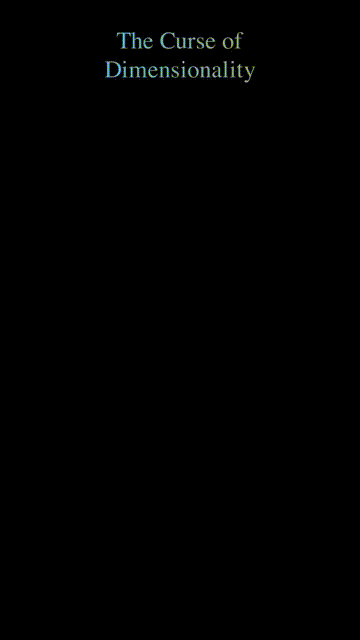

# Intuitive example:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [1]:
def generate_grid(points_per_axis: int, dim: int):
    axis = np.linspace(0, 1, points_per_axis)
    mesh = np.meshgrid(*([axis] * dim))
    grid = np.vstack([m.ravel() for m in mesh]).T
    return grid


In [ ]:
def plot_1d(points):
    plt.figure()
    plt.scatter(points[:, 0], np.zeros(len(points)))
    plt.title(f"1D space: {len(points)} points")
    plt.xlabel("x")
    plt.yticks([])
    plt.show()


def plot_2d(points):
    """
    Plot points in 2D space.
    
    Args:
        points (np.ndarray): shape (N, 2)
    """
    plt.figure()
    plt.scatter(points[:, 0], points[:, 1])
    plt.title(f"2D space: {len(points)} points")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_3d(points):
    """
    Plot points in 3D space.
    
    Args:
        points (np.ndarray): shape (N, 3)
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2])
    ax.set_title(f"3D space: {len(points)} points")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.show()


In [2]:
def visualize_density(points_per_axis: int):
    grid_1d = generate_grid(points_per_axis, dim=1)
    grid_2d = generate_grid(points_per_axis, dim=2)
    grid_3d = generate_grid(points_per_axis, dim=3)

    plot_1d(grid_1d)
    plot_2d(grid_2d)
    plot_3d(grid_3d)

    print("Points required with the same density:")
    print(f"1D: {len(grid_1d)}")
    print(f"2D: {len(grid_2d)}")
    print(f"3D: {len(grid_3d)}")


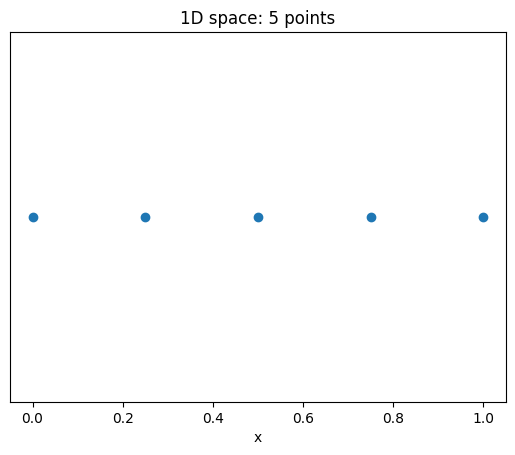

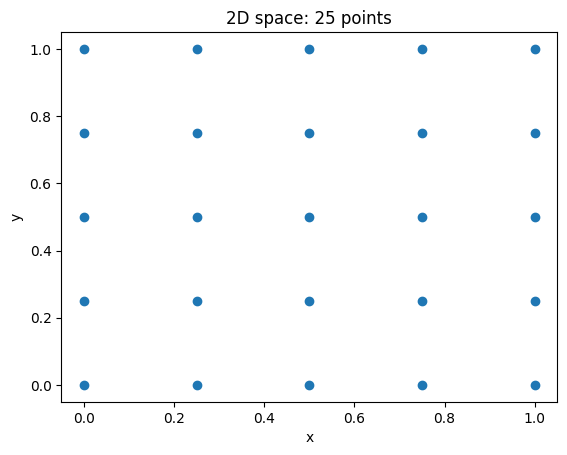

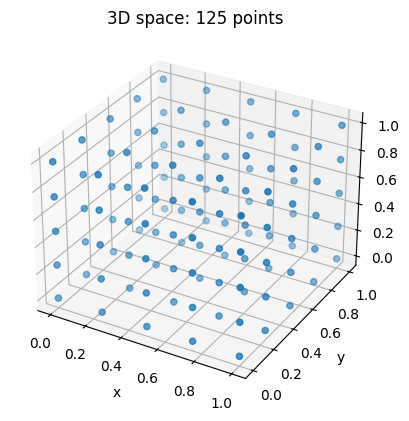

Points required with the same density:
1D: 5
2D: 25
3D: 125


In [9]:
visualize_density(points_per_axis=5)


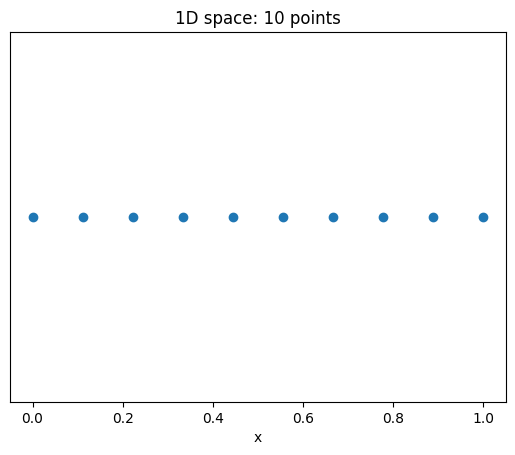

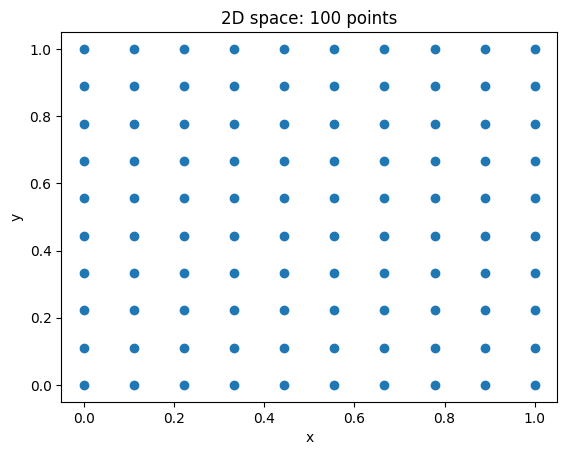

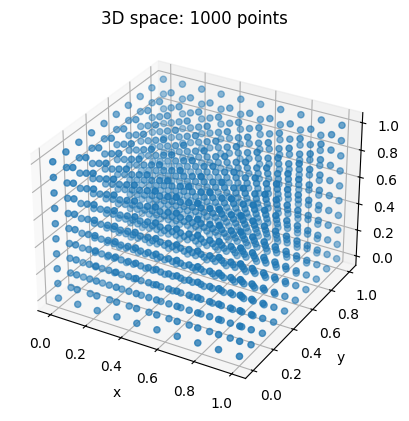

Points required with the same density:
1D: 10
2D: 100
3D: 1000


In [11]:
visualize_density(points_per_axis=10)
